# **Kaggle Challenge 3: Đề tài dự đoán thể loại nhạc.**
# **PHẦN 2: PHÂN TÍCH KHÁM PHÁ DỮ LIỆU**

## 1. Mô tả vấn đề
+ **Mô tả**:
   - Dự báo giá nhà dựa trên 17 tính chất của dataset nhà ở tại Ames, Iowa.
   - Dữ liệu đầu vào gồm 2 file:
      * train_clean.pkl: Dữ liệu từ file train đã được xử lý ở phần 1.
      * test_clean.pkl: Dữ liệu từ file test đã được xử lý ở phần 1.

+ **Mục tiêu**:
   - Phân tích và khám phá, tìm đặc trưng của các cột trong dữ liệu.

## 2. Chuẩn bị vấn đề

### 2.1. Import các thư viện cần thiết.

In [2]:
# Load libraries
from IPython import display
import numpy as np
import pickle

import matplotlib.pyplot as plt
import random

import pandas as pd
import seaborn as sns

import re

# pd.set_option('display.max_rows', None) # hiện tất cả các cột

### 2.2. Lấy dữ liệu từ dataset.

In [3]:
train_data = pd.DataFrame(pd.read_pickle("../clean/data/train_clean.pkl"))
test_data = pd.DataFrame(pd.read_pickle("../clean/data/test_clean.pkl"))

### 2.3. Kiểm tra dữ liệu dataset train và test

In [4]:
train_data.head()

,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
0,Marina Maximilian,Not Afraid,37.0,0.334,0.536,9.0,-6.649,0,0.0381,0.378000,0.003475,0.106,0.235,152.429,204947.0,4,9
1,The Black Keys,Howlin' for You,67.0,0.725,0.747,11.0,-5.545,1,0.0876,0.027200,0.046800,0.104,0.380,132.921,191956.0,4,6
2,Royal & the Serpent,phuck u,44.0,0.584,0.804,7.0,-6.094,1,0.0619,0.000968,0.635000,0.284,0.635,159.953,161037.0,4,10
3,Detroit Blues Band,Missing You,12.0,0.515,0.308,5.0,-14.711,1,0.0312,0.907000,0.021300,0.300,0.501,172.472,298093.0,3,2
4,Coast Contra,My Lady,48.0,0.565,0.777,6.0,-5.096,0,0.2490,0.183000,0.003475,0.211,0.619,88.311,254145.0,4,5


In [5]:
test_data.head()

,Artist Name,Track Name,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature
0,Juan Pablo Vega,Matando (feat. Vic Mirallas),44.0,0.691,0.670,2.0,-7.093,0,0.0941,0.075700,0.035200,0.1970,0.635,89.965,200000.0,4
1,Kappi Kat,Baarish,14.0,0.461,0.777,2.0,-7.469,1,0.0306,0.388000,0.923000,0.2910,0.525,163.043,283909.0,4
2,Plain White T's,Hey There Delilah,80.0,0.656,0.291,2.0,-10.572,1,0.0293,0.872000,0.002445,0.1140,0.298,103.971,232533.0,4
3,WALK THE MOON,Different Colors,52.0,0.480,0.826,6.0,-4.602,1,0.0397,0.000797,0.000001,0.1250,0.687,96.000,222053.0,4
4,Peled,◊ß◊®◊ô◊ñ,23.0,0.734,0.729,1.0,-6.381,0,0.2830,0.147000,0.004930,0.0672,0.805,76.030,118439.0,4


In [6]:
train_data.describe()

,Popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_in min/ms,time_signature,Class
count,14396.000000,14396.000000,14396.000000,14396.000000,14396.000000,14396.000000,14396.000000,14396.000000,14396.000000,14396.000000,14396.000000,14396.000000,1.439600e+04,14396.000000,14396.000000
mean,44.513059,0.543105,0.662422,5.951445,-7.900852,0.640247,0.080181,0.246746,0.135353,0.195782,0.486379,122.695372,2.000942e+05,3.924354,6.695679
std,17.216466,0.165517,0.235967,3.017105,4.057362,0.479944,0.085157,0.310922,0.274623,0.159258,0.239476,29.538490,1.116891e+05,0.359520,3.206170
min,1.000000,0.059600,0.001210,1.000000,-39.952000,0.000000,0.022500,0.000000,0.000001,0.011900,0.021500,30.557000,5.016500e-01,1.000000,0.000000
25%,33.000000,0.432000,0.508000,4.000000,-9.538000,0.000000,0.034800,0.004280,0.000295,0.097275,0.299000,99.799000,1.654458e+05,4.000000,5.000000
50%,44.000000,0.545000,0.699000,6.000000,-7.013500,1.000000,0.047100,0.081450,0.003490,0.129000,0.480500,120.060000,2.089410e+05,4.000000,8.000000
75%,56.000000,0.658000,0.861000,8.000000,-5.162000,1.000000,0.083100,0.432250,0.057700,0.256000,0.672000,141.988250,2.522470e+05,4.000000,10.000000
max,100.000000,0.989000,1.000000,11.000000,1.342000,1.000000,0.955000,0.996000,0.996000,0.992000,0.986000,217.416000,1.477187e+06,5.000000,10.000000


## 3. Phân tích khai phá dữ liệu

### 3.1. Phân tích đơn biến

#### **1) Các biến số**

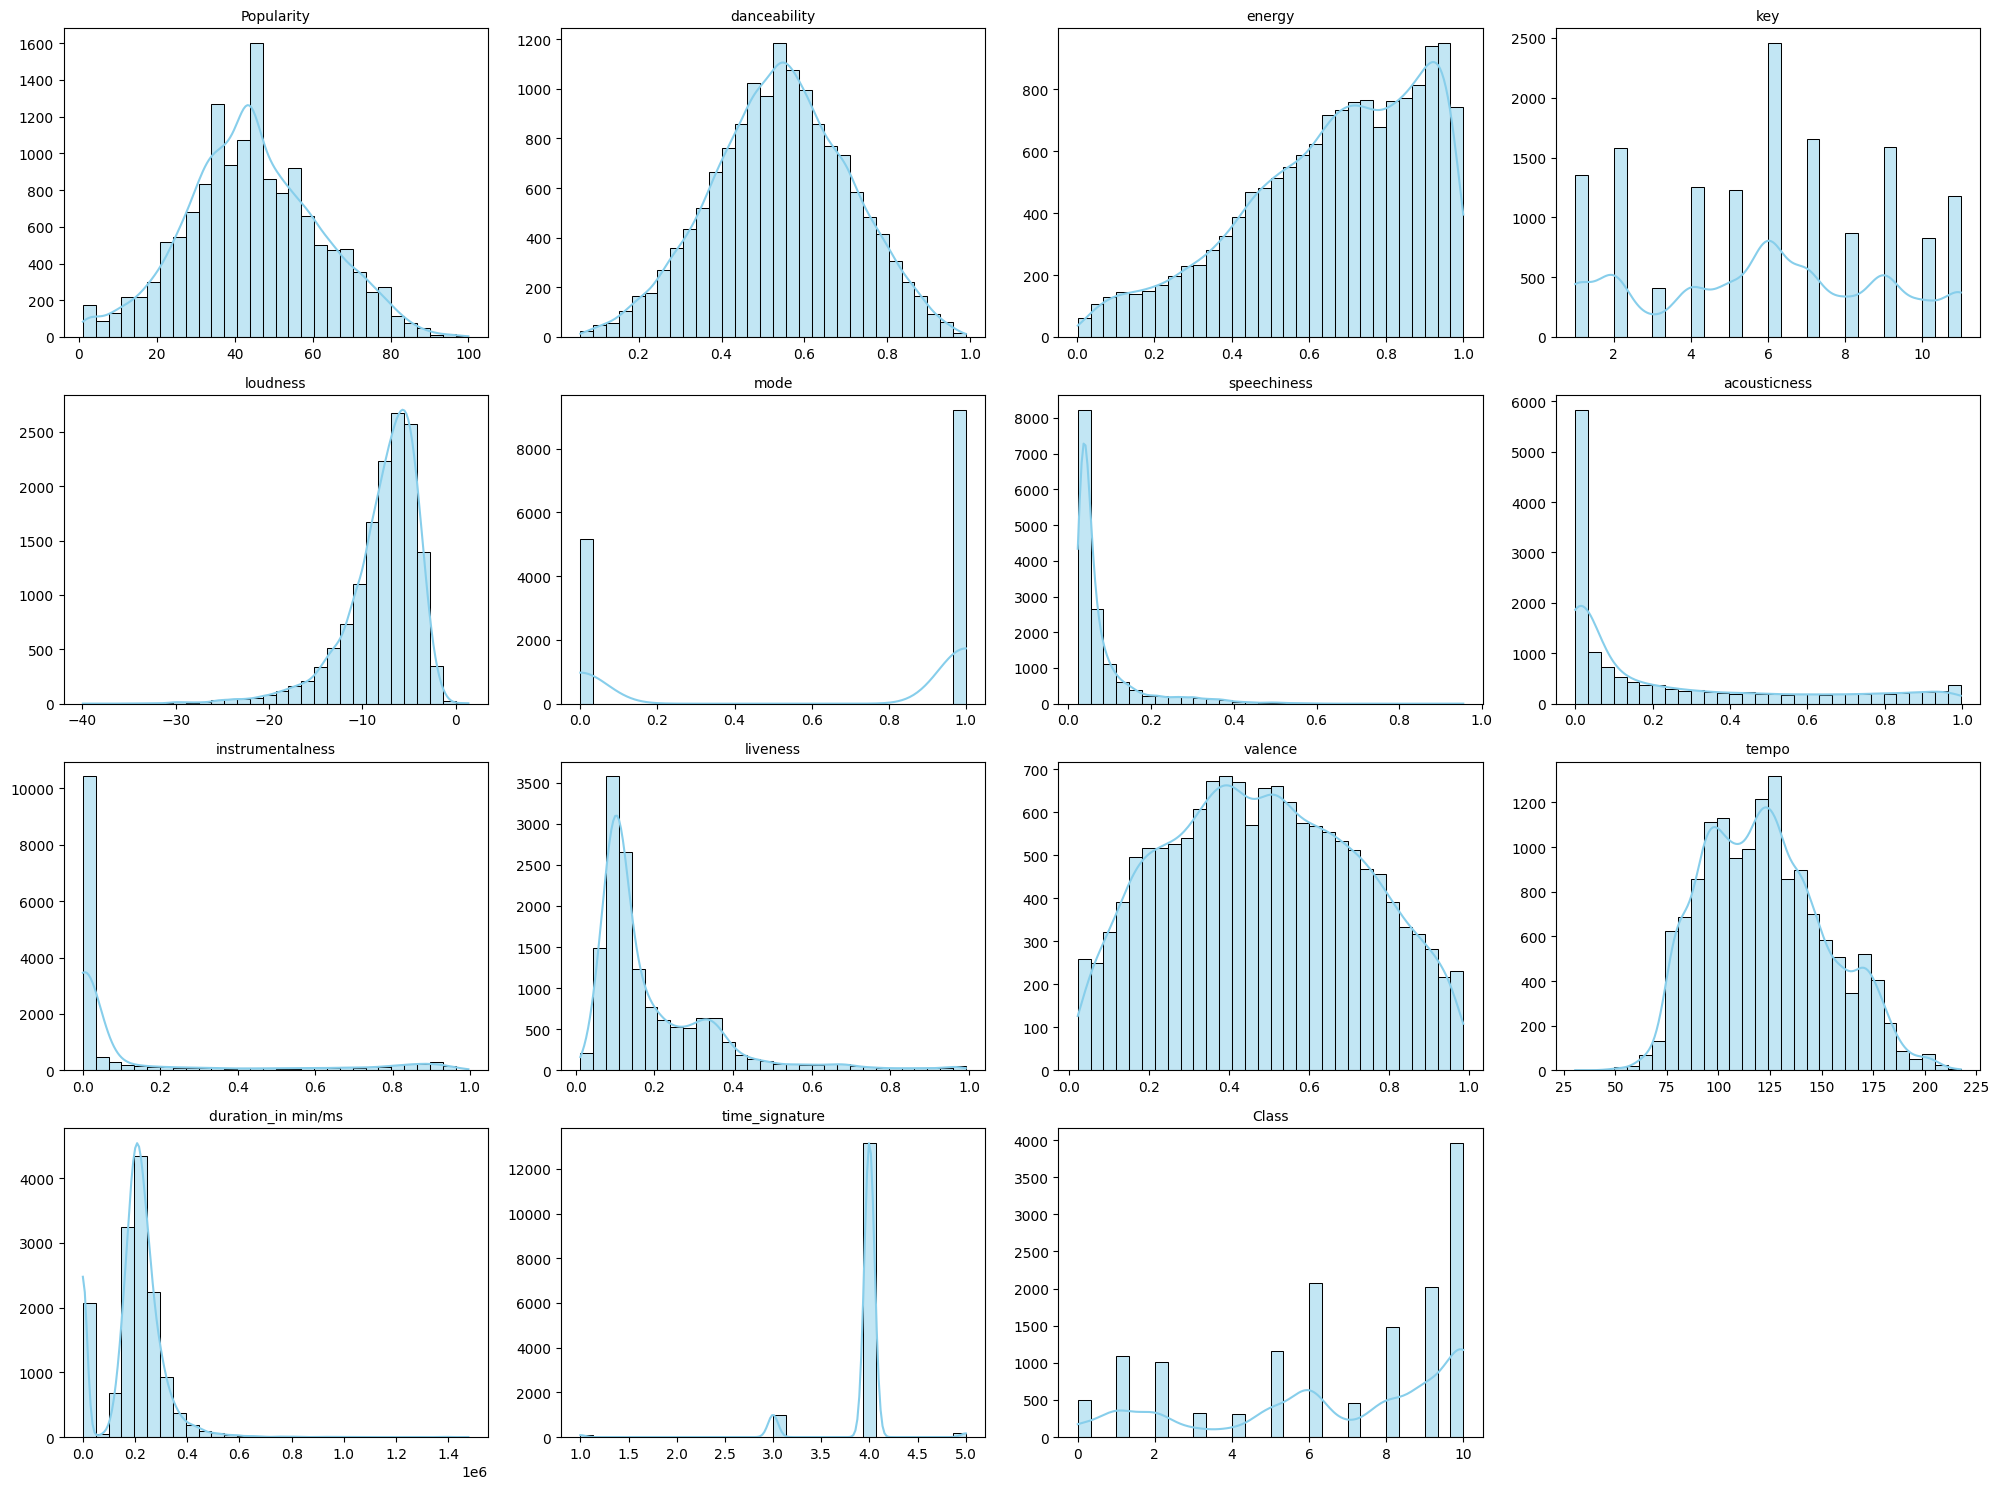

In [7]:
# Tạo lưới biểu đồ
fig, axes = plt.subplots(4, 4, figsize=(20, 15))
axes = axes.flatten()

# Lặp qua các cột trong dataframe
for i, col in enumerate(train_data.select_dtypes(include=['int64', 'float64']).columns):
    sns.histplot(train_data[col], bins=30, kde=True, color='skyblue', ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# Xóa các subplot không dùng đến (dư thừa)
for j in range(len(train_data.select_dtypes(include=['int64', 'float64']).columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("fig_hist1.png")
plt.show()

**Nhận xét:**
- Cột Popularity có phân bố gần chuẩn, chỉ có một số phần tử ở khoảng 30 - 50 phân bố tương đối nhiều hơn mức bình thường.
- Cột Danceability có phân bố rất gần với dạng chuẩn, có thể không cần biến đổi chuẩn hóa dữ liệu.
- Cột Energy, Loudness có phân bố với xu hướng lệch trái.
- Cột Speechiness, Acousticness, Instrumentalness có phân bố với xu hướng lệch phải mạnh.
- Cột Liveness có phân bố với xu hướng lệch phải.
- Cột Valence có phân bố đồng đều nhưng không phải phân bố chuẩn (phân bố hình bán nguyệt).
- Cột Tempo có phân bố lệch với dạng phân phối chuẩn.
- Cột Duration_in min/ms có phân bố lệch phải và có nhiều giá trị gần 0.
- Cột Key có phân bố rời rạc, với giá trị 6 có phân bố lớn nhất.
- Cột Mode có phân bố rời rạc, với giá trị 1 có phân bố lớn nhất.
- Cột Time_signature có phân bố rời rạc, với giá trị 4 phân bố nhiều nhất.

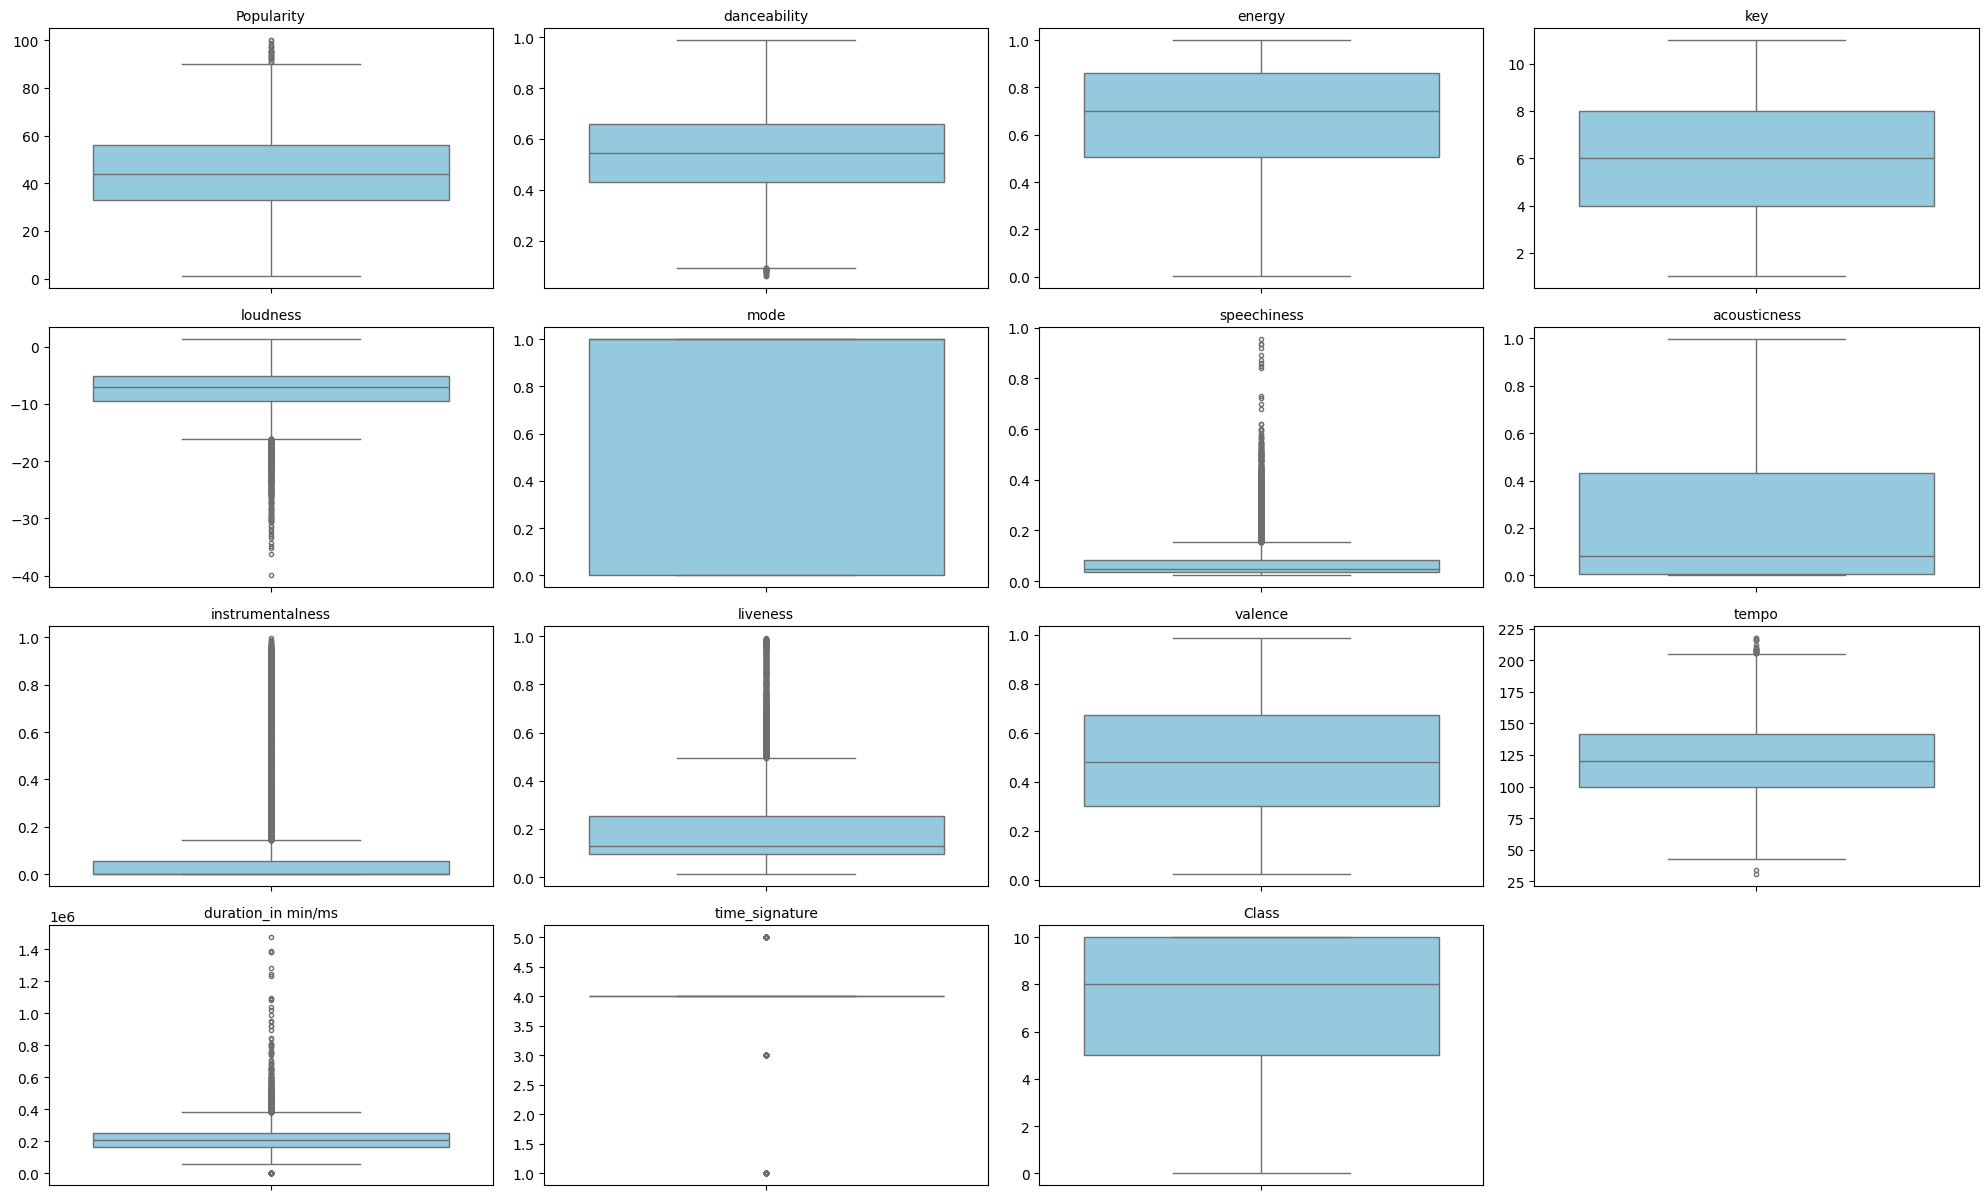

In [8]:
# Tạo lưới biểu đồ
fig, axes = plt.subplots(10, 4, figsize=(20, 30))
axes = axes.flatten()

# Lặp qua các cột trong dataframe
for i, col in enumerate(train_data.select_dtypes(include=['int64', 'float64']).columns):
    sns.boxplot(train_data[col], color="skyblue", fliersize=3, linewidth=1, ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# Xóa các subplot không dùng đến (dư thừa)
for j in range(len(train_data.select_dtypes(include=['int64', 'float64']).columns), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Nhận xét:**
- Cột Popularity, Danceability có phân bố gần chuẩn với ít giá trị ngoại lai.
- Cột Energy có phân bố lệch trái nhưng không có giá trị ngoại lai.
- Cột Spechiness, Instrumentalness, Liveness, Duration_in min/ms có phân bố lệch phải với nhiều giá trị ngoại lai.

#### **2) Biến Artist Name**

In [9]:
print(f"Số tên nghệ sĩ trên số dòng tập dữ liệu train: {len(train_data["Artist Name"].unique())} / {len(train_data["Artist Name"])}")
print(f"Số tên nghệ sĩ trên số dòng tập dữ liệu test: {len(test_data["Artist Name"].unique())} / {len(test_data["Artist Name"])}")

Số tên nghệ sĩ trên số dòng tập dữ liệu train: 7913 / 14396
Số tên nghệ sĩ trên số dòng tập dữ liệu test: 2784 / 3600


**Nhận xét:**
- Có một số nghệ sĩ trong tập train và test sáng tác nhiều hơn 1 bản nhạc.

In [10]:
train_data["Artist Name"].value_counts(ascending=False).to_frame("Count").head(10)

,Count
Artist Name,
Backstreet Boys,58
Westlife,53
Britney Spears,47
Omer Adam,39
Eyal Golan,38
Shlomo Artzi,32
Dudu Aharon,29
Hadag Nahash,29
Arik Einstein,29


**Nhận xét:**
- Nghệ sĩ Backstreet Boys sáng tác nhiều bản nhạc nhất với 58 bài.

In [11]:
print(f"Số nghệ sĩ có nhiều hơn 1 bản nhạc: {(train_data["Artist Name"].value_counts() > 1).sum()}")

Số nghệ sĩ có nhiều hơn 1 bản nhạc: 2624


**Nhận xét:**
- Có 2624 nghệ sĩ có nhiều hơn 1 bản nhạc trong tập train.

#### **3) Biến Track Name** 

In [12]:
print(f"Số tên bản nhạc trên số dòng tập dữ liệu train: {len(train_data["Track Name"].unique())} / {len(train_data["Track Name"])}")
print(f"Số tên bản nhạc trên số dòng tập dữ liệu test: {len(test_data["Track Name"].unique())} / {len(test_data["Track Name"])}")

Số tên bản nhạc trên số dòng tập dữ liệu train: 12455 / 14396
Số tên bản nhạc trên số dòng tập dữ liệu test: 3472 / 3600


**Nhận xét:**
- Có một số bản nhạc trong tập train và test xuất hiện nhiều hơn 1 lần.

In [13]:
train_data["Track Name"].value_counts(ascending=False).to_frame("Count").head(10)

,Count
Track Name,
Fire,8
Ghost,7
Runaway,7
Control,6
Hurricane,6
Forever,6
Dreams,6
Blue,5
Run,5


**Nhận xét:**
- Bản nhạc "Fire" xuất hiện nhiều nhất (8 lần).

In [14]:
print(f"Số bản nhạc xuất hiện nhiều hơn 1 lần: {(train_data["Track Name"].value_counts() > 1).sum()}")

Số bản nhạc xuất hiện nhiều hơn 1 lần: 1526


**Nhận xét:**
- Có 1526 bản nhạc xuất hiện nhiều hơn 1 lần.

### 3.2. Phân tích hai biến

#### **1) Các biến số liên tục với biến mục tiêu (Class)**

##### a. Biến Popularity

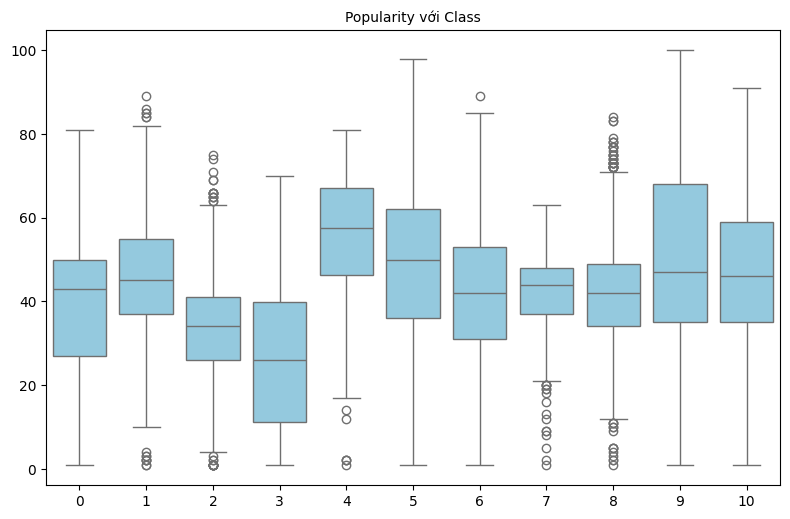

In [15]:
# Chọn các cột rời rạc.
num_cols = ["Popularity"]

# Tạo lưới biểu đồ
fig, axes = plt.subplots(2, 1, figsize=(8, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        x=train_data['Class'],
        y=train_data[col],
        ax=axes[i],
        color='skyblue'
    )
    axes[i].set_title(f'{col} với Class', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')


for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("fig_box_popularity.png", dpi=150, bbox_inches='tight')
plt.show()

**Nhận xét:**
- Giá trị 4, 5 có phân bố trung bình cao nhất.
- Giá trị 2, 3 có phân bố trung bình thấp nhất.
- Giá trị 7, 8 có nhiều giá trị ngoại lai.

##### b. Biến Danceability

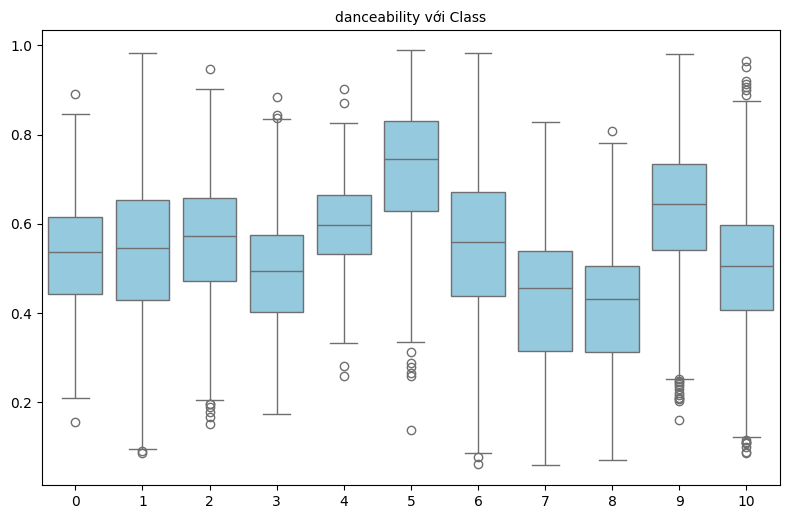

In [16]:

num_cols = ["danceability"]

# Tạo lưới biểu đồ
fig, axes = plt.subplots(2, 1, figsize=(8, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        x=train_data['Class'],
        y=train_data[col],
        ax=axes[i],
        color='skyblue'
    )
    axes[i].set_title(f'{col} với Class', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')


for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("fig_box_danceability.png", dpi=150, bbox_inches='tight')
plt.show()

**Nhận xét:**
- Giá trị 5, 9 có phân bố trung bình cao nhất.
- Giá trị 7, 8 có phân bố trung bình thấp nhất.

##### c. Biến Energy

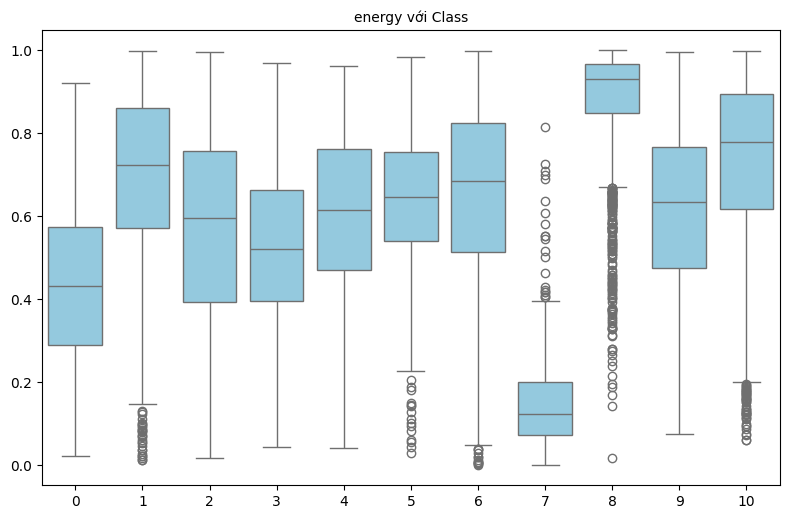

In [17]:

num_cols = ["energy"]

# Tạo lưới biểu đồ
fig, axes = plt.subplots(2, 1, figsize=(8, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        x=train_data['Class'],
        y=train_data[col],
        ax=axes[i],
        color='skyblue'
    )
    axes[i].set_title(f'{col} với Class', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')


for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("fig_box_energy.png", dpi=150, bbox_inches='tight')
plt.show()

**Nhận xét:**
- Giá trị 8 có phân bố trung bình cao nhất với nhiều giá trị ngoại lai.
- Giá trị 7 có phân bố trung bình thấp nhất.
- Giá trị 1, 10 có nhiều giá trị ngoại lai.

##### d. Biến loudness

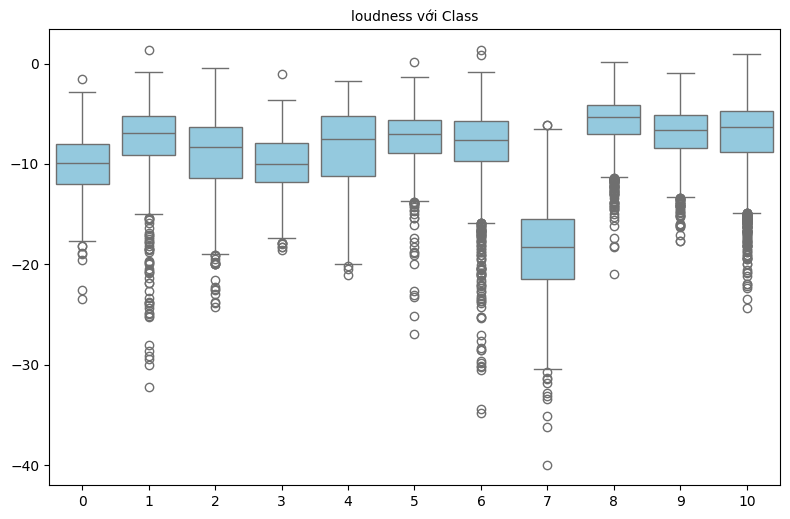

In [18]:

num_cols = ["loudness"]

# Tạo lưới biểu đồ
fig, axes = plt.subplots(2, 1, figsize=(8, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        x=train_data['Class'],
        y=train_data[col],
        ax=axes[i],
        color='skyblue'
    )
    axes[i].set_title(f'{col} với Class', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')


for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("fig_box_loudness.png", dpi=150, bbox_inches='tight')
plt.show()

**Nhận xét:**
- Giá trị 7 có phân bố trung bình cao nhất.
- Hầu hết các giá trị có nhiều giá trị ngoại lai.

##### e. Biến speechiness

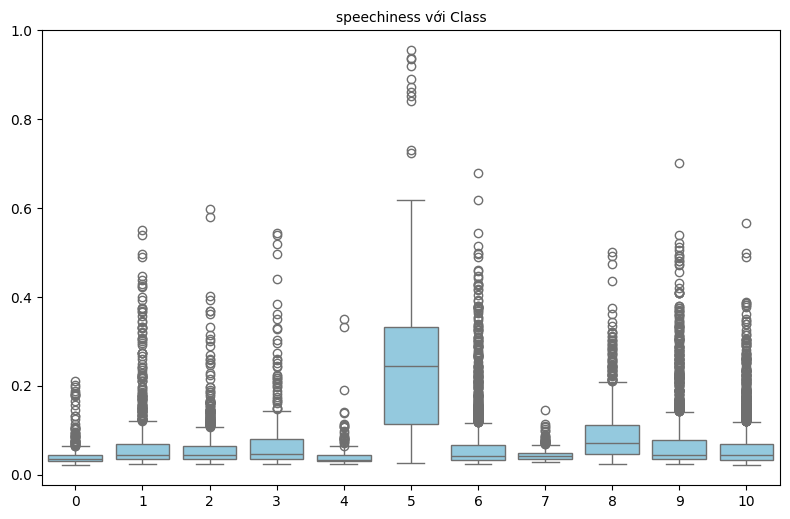

In [19]:

num_cols = ["speechiness"]

# Tạo lưới biểu đồ
fig, axes = plt.subplots(2, 1, figsize=(8, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        x=train_data['Class'],
        y=train_data[col],
        ax=axes[i],
        color='skyblue'
    )
    axes[i].set_title(f'{col} với Class', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')


for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("fig_box_loudness.png", dpi=150, bbox_inches='tight')
plt.show()

**Nhận xét:**
- Giá trị 5 có phân bố trung bình cao nhất.
- Hầu hết các giá trị khác phân bố thấp hơn với nhiều giá trị ngoại lai.
- Giá trị 7 phân tán ít.

##### f. Biến acousticness

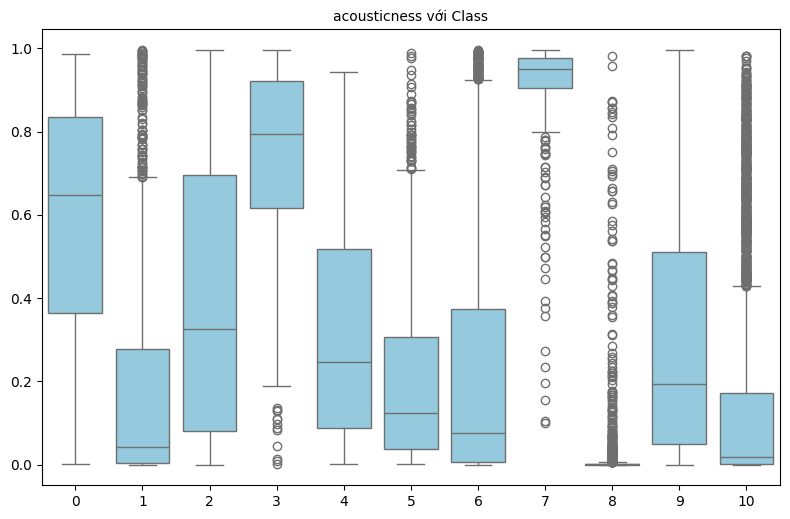

In [20]:

num_cols = ["acousticness"]

# Tạo lưới biểu đồ
fig, axes = plt.subplots(2, 1, figsize=(8, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        x=train_data['Class'],
        y=train_data[col],
        ax=axes[i],
        color='skyblue'
    )
    axes[i].set_title(f'{col} với Class', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')


for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("fig_box_acousticness.png", dpi=150, bbox_inches='tight')
plt.show()

**Nhận xét:**
- Giá trị 7 có phân bố trung bình cao nhất.
- Giá trị 8 có phân bố trung bình thấp nhất với nhiều giá trị ngoại lai.
- Giá trị 1, 5, 6, 10 có nhiều giá trị ngoại lai.

##### g. Biến instrumentalness

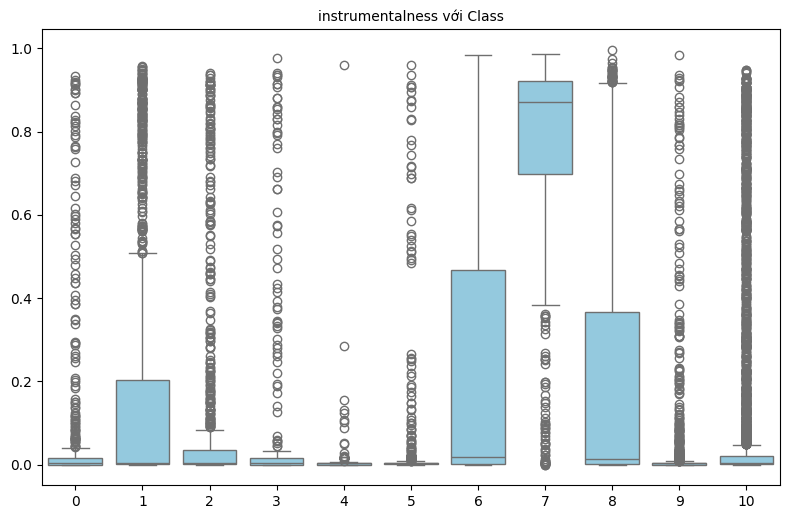

In [21]:

num_cols = ["instrumentalness"]

# Tạo lưới biểu đồ
fig, axes = plt.subplots(2, 1, figsize=(8, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        x=train_data['Class'],
        y=train_data[col],
        ax=axes[i],
        color='skyblue'
    )
    axes[i].set_title(f'{col} với Class', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')


for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("fig_box_acousticness.png", dpi=150, bbox_inches='tight')
plt.show()

**Nhận xét:**
- Giá trị 7 có phân bố trung bình cao nhất.
- Hầu hết các giá trị khác phân bố thấp hơn với nhiều giá trị ngoại lệ.

##### h. Biến liveness

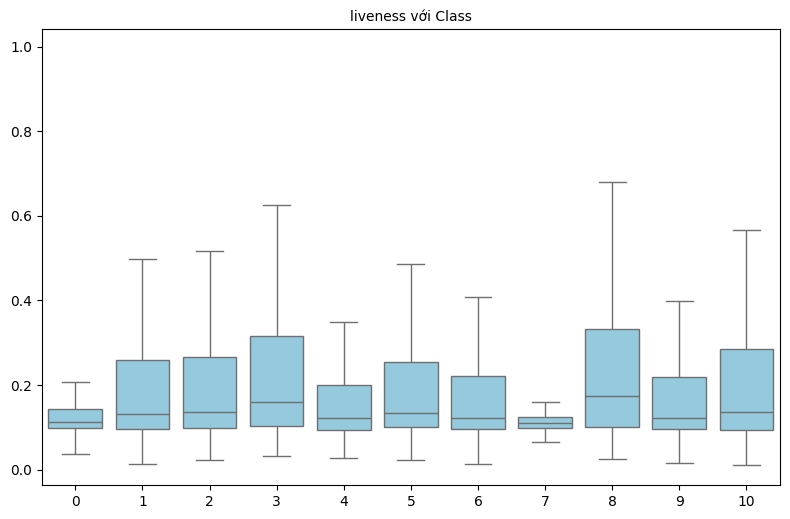

In [22]:
num_cols = ["liveness"]

# Tạo lưới biểu đồ
fig, axes = plt.subplots(2, 1, figsize=(8, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    # Vẽ boxplot
    sns.boxplot(
        x=train_data['Class'],
        y=train_data[col],
        ax=axes[i],
        color='skyblue',
        fliersize=0  # ẩn outliers vì stripplot sẽ hiển thị điểm
    )
    
    axes[i].set_title(f'{col} với Class', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("fig_box_strip_liveness.png", dpi=150, bbox_inches='tight')
plt.show()


**Nhận xét:**
- Giá trị 3, 8 phân tán nhiều.
- Giá trị 0, 7 phân tán ít.

##### i. Biến valence

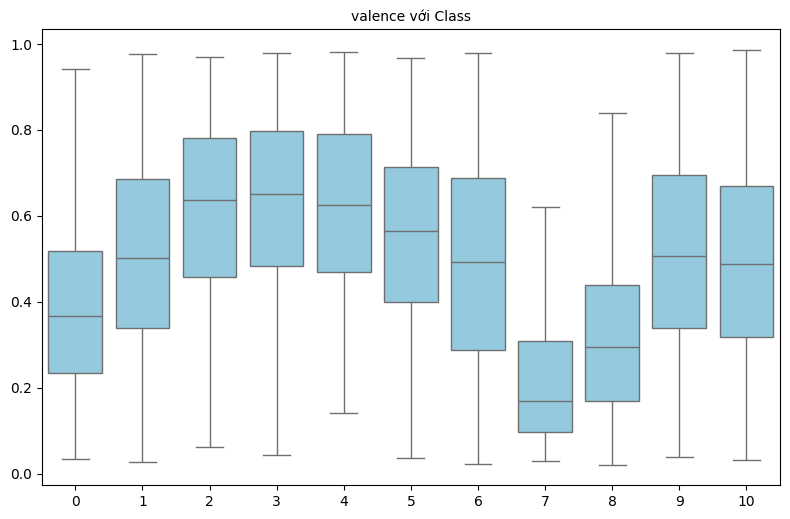

In [23]:
num_cols = ["valence"]

# Tạo lưới biểu đồ
fig, axes = plt.subplots(2, 1, figsize=(8, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    # Vẽ boxplot
    sns.boxplot(
        x=train_data['Class'],
        y=train_data[col],
        ax=axes[i],
        color='skyblue',
        fliersize=0  # ẩn outliers vì stripplot sẽ hiển thị điểm
    )
    
    axes[i].set_title(f'{col} với Class', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("fig_box_strip_valence.png", dpi=150, bbox_inches='tight')
plt.show()


**Nhận xét:**
- Giá trị 7, 8 có phân bố trung bình thấp nhất.
- Giá trị 2, 3, 4 có phân bố trung bình cao nhất.

##### j. Biến tempo

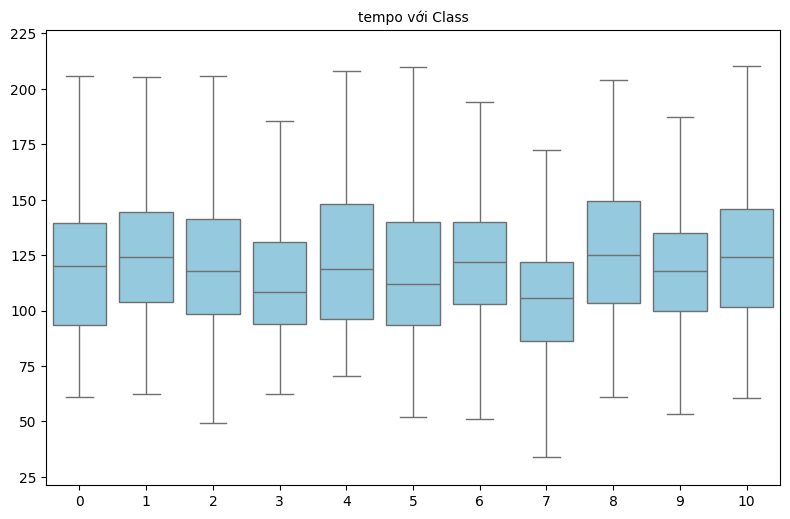

In [24]:
num_cols = ["tempo"]

# Tạo lưới biểu đồ
fig, axes = plt.subplots(2, 1, figsize=(8, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    # Vẽ boxplot
    sns.boxplot(
        x=train_data['Class'],
        y=train_data[col],
        ax=axes[i],
        color='skyblue',
        fliersize=0  # ẩn outliers vì stripplot sẽ hiển thị điểm
    )
    
    axes[i].set_title(f'{col} với Class', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("fig_box_strip_tempo.png", dpi=150, bbox_inches='tight')
plt.show()


**Nhận xét:**
- Giá trị 3, 7 có phân bố trung bình thấp nhất.

##### k. Biến duration_in min/ms

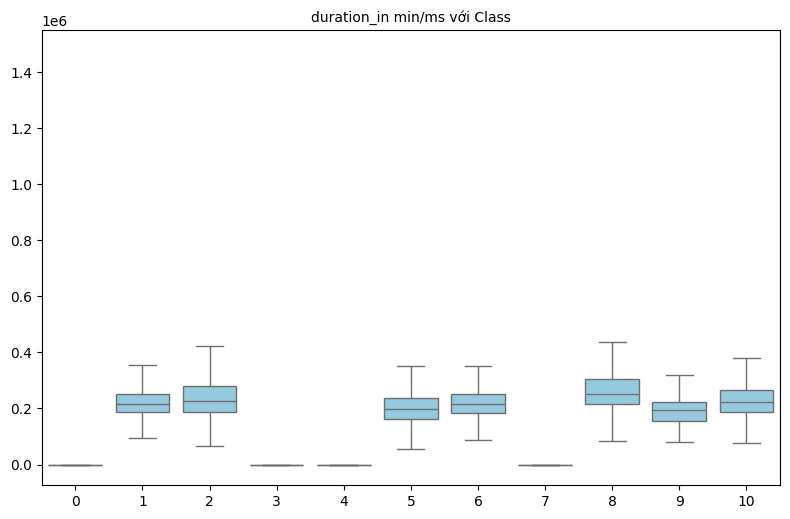

In [25]:
num_cols = ["duration_in min/ms"]

# Tạo lưới biểu đồ
fig, axes = plt.subplots(2, 1, figsize=(8, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    # Vẽ boxplot
    sns.boxplot(
        x=train_data['Class'],
        y=train_data[col],
        ax=axes[i],
        color='skyblue',
        fliersize=0  # ẩn outliers vì stripplot sẽ hiển thị điểm
    )
    
    axes[i].set_title(f'{col} với Class', fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

for j in range(len(num_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("fig_box_strip_duration.png", dpi=150, bbox_inches='tight')
plt.show()


**Nhận xét:**
- Giá trị 0, 3, 4, 7 có phân bố trung bình thấp nhất và phân tán ít nhất.
- Các giá trị khác có phân bố trung bình cao hơn và phân tán nhiều hơn.

##### l. Hiển thị biểu đồ cho các biến

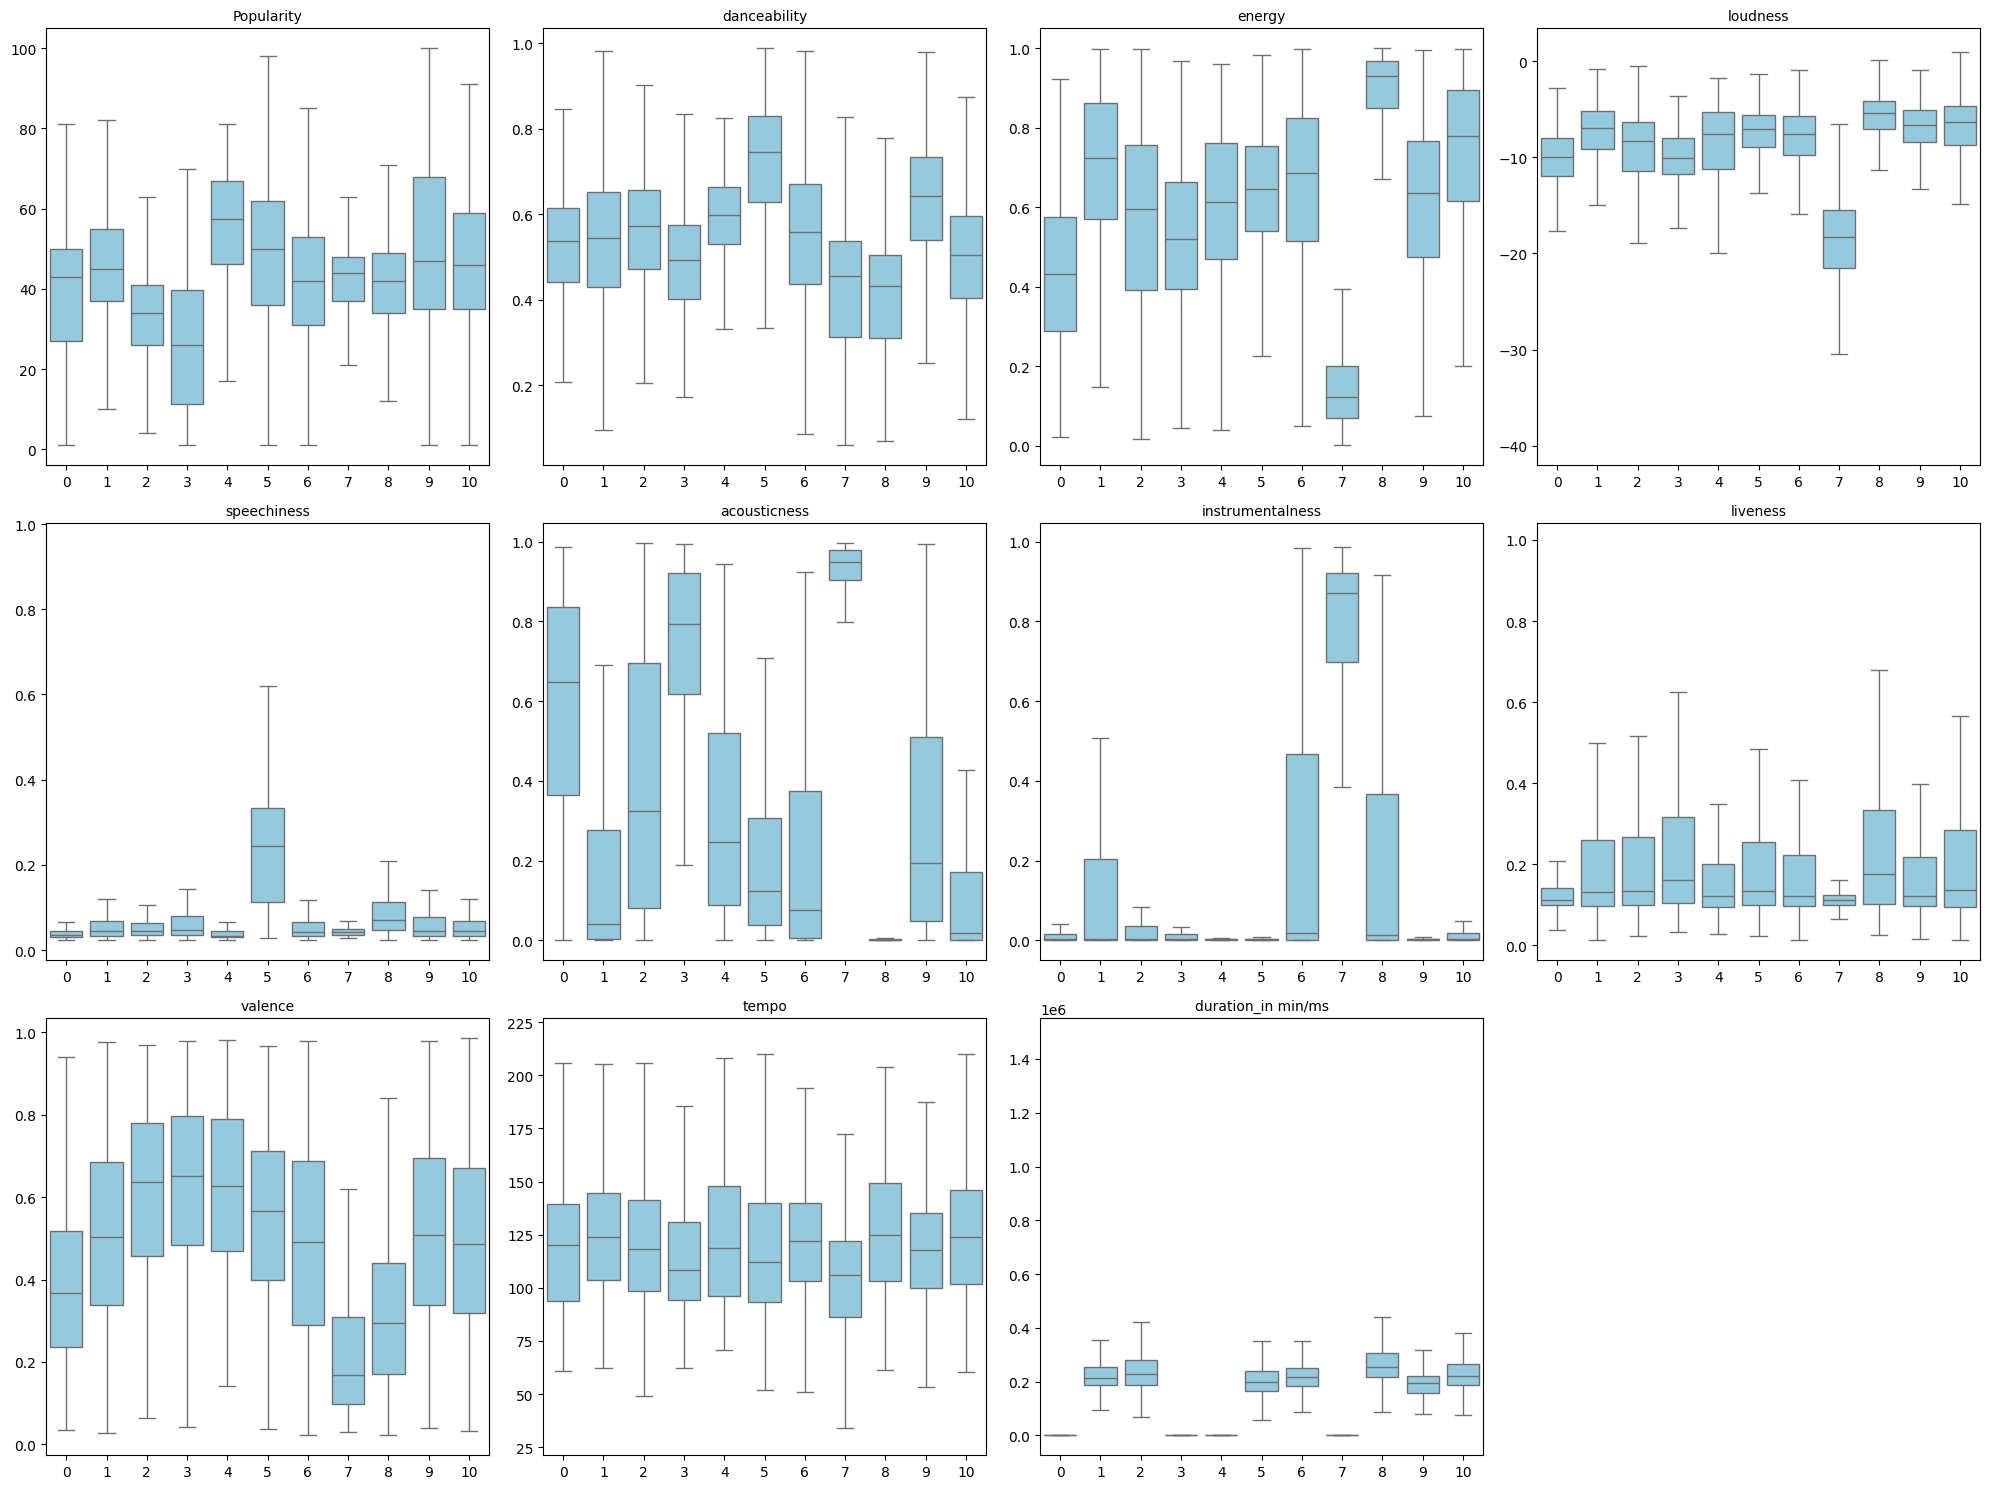

In [26]:
cols = ["Popularity", "danceability", "energy", "loudness", "speechiness", "acousticness",
        "instrumentalness", "liveness", "valence", "tempo", "duration_in min/ms"]

# Tạo lưới biểu đồ
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
axes = axes.flatten()

# Lặp qua các cột trong dataframe
for i, col in enumerate(cols):
    sns.boxplot(
        x=train_data['Class'],
        y=train_data[col],
        ax=axes[i],
        color='skyblue',
        fliersize=0  # ẩn outliers vì stripplot sẽ hiển thị điểm
    )
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

# Xóa các subplot không dùng đến (dư thừa)
for j in range(len(cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("fig_box_numbers.png")
plt.show()

#### **2) Các biến số rời rạc với biến mục tiêu (Class)**

##### a. Biến key

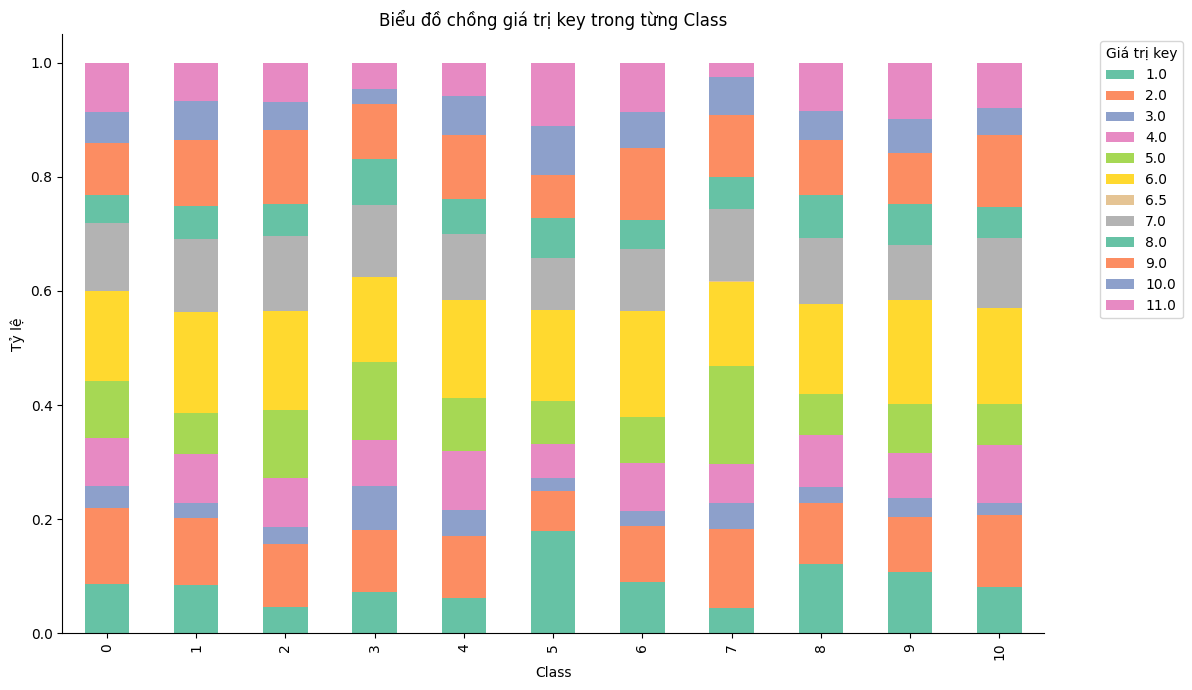

In [44]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Tính tần suất xuất hiện của từng key trong từng Class
count_df = (
    train_data.groupby(['Class', 'key'])
    .size()
    .reset_index(name='count')
)

# Pivot để tạo dạng bảng cột chồng
pivot_df = count_df.pivot(index='Class', columns='key', values='count').fillna(0)

# (Tùy chọn) chuyển sang tỉ lệ %
pivot_df = pivot_df.div(pivot_df.sum(axis=1), axis=0)

# Vẽ stacked bar chart
colors = sns.color_palette("Set2", len(pivot_df.columns))
pivot_df.plot(
    kind='bar',
    stacked=True,
    color=colors,
    figsize=(12, 7)
)

plt.title("Biểu đồ chồng giá trị key trong từng Class", fontsize=12)
plt.xlabel("Class")
plt.ylabel("Tỷ lệ")
plt.legend(
    title="Giá trị key",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
sns.despine()
plt.tight_layout()
plt.show()


##### b. Biến mode

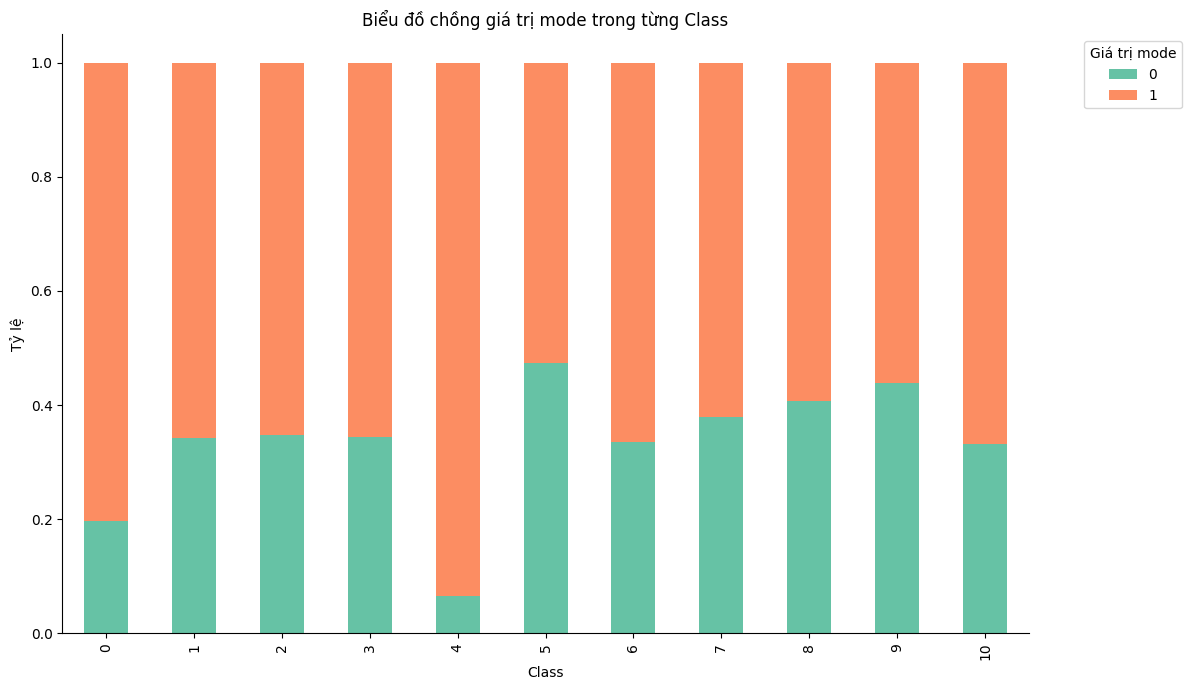

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Tính tần suất xuất hiện của từng mode trong từng Class
count_df = (
    train_data.groupby(['Class', 'mode'])
    .size()
    .reset_index(name='count')
)

# Pivot để tạo dạng bảng cột chồng
pivot_df = count_df.pivot(index='Class', columns='mode', values='count').fillna(0)

# (Tùy chọn) chuyển sang tỉ lệ %
pivot_df = pivot_df.div(pivot_df.sum(axis=1), axis=0)

# Vẽ stacked bar chart
colors = sns.color_palette("Set2", len(pivot_df.columns))
pivot_df.plot(
    kind='bar',
    stacked=True,
    color=colors,
    figsize=(12, 7)
)

plt.title("Biểu đồ chồng giá trị mode trong từng Class", fontsize=12)
plt.xlabel("Class")
plt.ylabel("Tỷ lệ")
plt.legend(
    title="Giá trị mode",
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)
sns.despine()
plt.tight_layout()
plt.show()


#### **3) Biến Artist Name với biến mục tiêu (Class)**